Four histograms, 

In [430]:
import pandas as pd
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import numpy as np

from scipy.stats import gaussian_kde

# Project Level

In [431]:
df_proj = pd.read_csv("../proj_level_py.csv")

In [432]:
df_proj.columns

Index(['Unnamed: 0', 'url', 'source', 'n_files', 'n_lines', 'n_chars',
       'n_blank_lines', 'n_imports', 'n_unique_imports', 'n_functions',
       'n_async_functions', 'class_count', 'n_at_end_of_code_line_block',
       'n_at_end_of_code_line_line', 'n_blank_in_docstring_block',
       'n_blank_in_docstring_line', 'n_comment_lines_block',
       'n_comment_lines_line', 'n_comments_block', 'n_comments_line',
       'n_fn_imports', 'n_fn_called', 'n_total_calls',
       'n_out_of_project_calls', 'convention', 'error', 'info', 'refactor',
       'warning', 'n_duplications', 'n_lines_py', 'n_comments_lines',
       'n_comments', 'avg_lines_in_comment', 'percent_comment_lines',
       'unique_imports_per_project', 'imports_per_code_line',
       'avg_file_length', 'percent_blank_lines', 'percent_code_lines'],
      dtype='str')

In [433]:
df_proj["percent_comments"] = df_proj['percent_comment_lines']
df_proj["percent_code"] = df_proj['percent_code_lines']
df_proj["percent_blank"] = df_proj['percent_blank_lines']

Individual

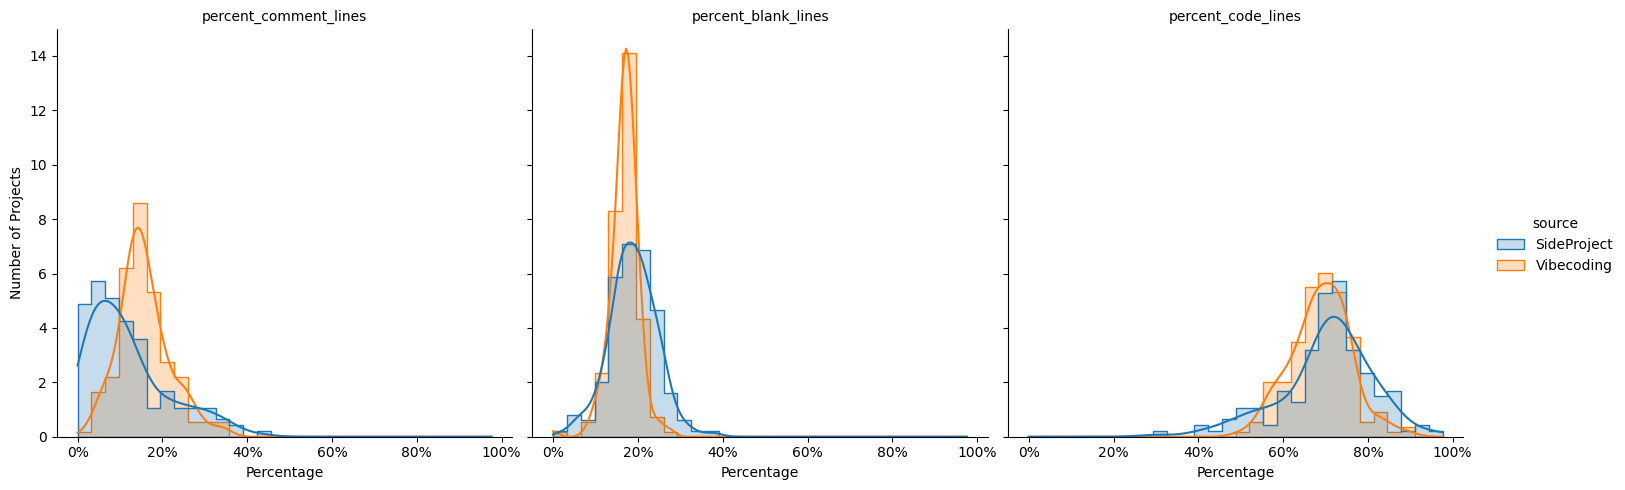

In [434]:


columns = [
    "percent_comment_lines",
    "percent_blank_lines",
    "percent_code_lines"
]

df_long = df_proj.melt(
    id_vars="source",
    value_vars=columns,
    var_name="line_type",
    value_name="percent"
)

g = sns.displot(
    data=df_long,
    x="percent",
    hue="source",
    col="line_type",
    kind="hist",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    kde=True,
    facet_kws={"sharex": False, "sharey": True}
)

g.set_axis_labels("Percentage", "Number of Projects")
g.set_titles("{col_name}")

# If values are between 0 and 1
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(PercentFormatter(1))

plt.show()

Grouped

In [435]:

def make_long(df_proj, columns):


    # Convert to long format
    df_long = df_proj.melt(
        id_vars="source",
        value_vars=columns,
        var_name="line_type",
        value_name="percent"
    )

    # Optional: cleaner labels
    df_long["line_type"] = df_long["line_type"].replace({
        "percent_comment_lines": "Comment",
        "percent_blank_lines": "Blank",
        "percent_code_lines": "Code",
        "percent_comments": "Comment",
        "percent_blank": "Blank",
        "percent_code": "Code",
    })

    df_long["source"] = df_long["source"].replace({
        "SideProject": "Control",
        "Vibecoding": "Vibecoded"
    })

    # Create six categories
    df_long["group"] = (
        df_long["source"] + " - " + df_long["line_type"]
    )
    return df_long



In [436]:
def make_graph(df_proj, columns):
    colors = {
        "Comment": "#0072B2",
        "Blank": "#E69F00",
        "Code": "#009E73"
    }

    linestyles = {
        "Control": "-",
        "Vibecoded": "--"
    }

    palette = {
        "Control - Comment": "blue",
        "Vibecoded - Comment": "lightblue",
        "Control - Blank": "red",
        "Vibecoded - Blank": "salmon",
        "Control - Code": "green",
        "Vibecoded - Code": "lightgreen"
    }
    df_long = make_long(df_proj, columns)

    sns.histplot(
        data=df_long,
        x="percent",
        hue="group",
        bins=30,
        element="step",
        fill=False,
        stat="density",
        common_norm=False,
        palette=palette,
        # kde=True
    )

    plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

    plt.xlabel("Percentage of Lines")
    plt.ylabel("Number of Projects")
    plt.tight_layout()
    plt.show()

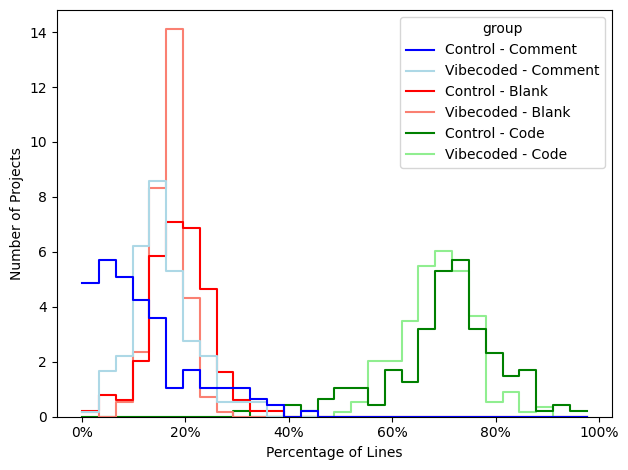

In [437]:
make_graph(df_proj, columns = ["percent_comment_lines", "percent_blank_lines", "percent_code_lines"])

# File Level

In [438]:
df_file = pd.read_csv("../file_level_py_raw.csv")

In [439]:
df_file.columns

Index(['Unnamed: 0', 'url', 'proj_name', 'file_path', 'file_name', 'extn',
       'n_lines', 'blank_lines', 'char', 'source', 'n_functions',
       'n_async_functions', 'class_count', 'n_at_end_of_code_line_block',
       'n_at_end_of_code_line_line', 'n_blank_in_docstring_block',
       'n_blank_in_docstring_line', 'n_comment_lines_block',
       'n_comment_lines_line', 'n_comments_block', 'n_comments_line',
       'n_imports', 'n_fn_imports', 'n_class_imports', 'n_calls',
       'n_unique_fn_calls', 'n_unique_class_calls', 'n_comments_lines',
       'n_comments', 'avg_lines_in_comment', 'n_code_lines',
       'n_external_fn_calls', 'n_external_fn_calls_by_code',
       'n_external_imports', 'n_internal_imports',
       'n_external_imports_by_code', 'blank_by_code', 'percent_comments',
       'char_by_code', 'n_functions_by_code', 'n_async_functions_by_code',
       'class_count_by_code', 'n_comment_lines_block_by_code',
       'n_comment_lines_line_by_code', 'n_imports_by_code', 'n_c

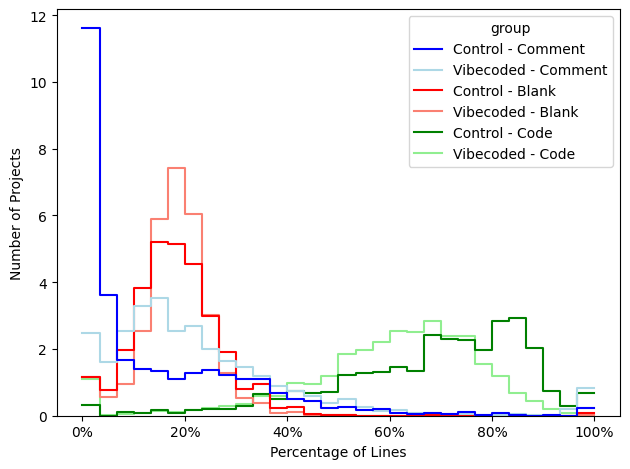

In [440]:
make_graph(df_file, columns = ["percent_comments", "percent_blank", "percent_code"])

In [441]:
filtered_df = df_file[df_file["percent_code"] < 0]

In [442]:
filtered_df.shape

(0, 57)

In [443]:
filtered_df.iloc[1]

IndexError: single positional indexer is out-of-bounds

# Class Level
Negative numbers (there are two of them), are from double-counting the block comments and the line comments

In [444]:
df_class = pd.read_csv("../class_level_metrics.csv")

In [445]:
df_class.columns

Index(['Unnamed: 0', 'url', 'commit', 'proj_name', 'file_path', 'file_name',
       'class_name', 'class_sig', 'line_count', 'fn_count', 'class_code',
       'n_functions', 'n_instance_vars', 'n_characters', 'n_line_comments',
       'line_comment_lines', 'n_block_comments', 'block_comment_lines',
       'block_comment_blank_line', 'double_count_lines', 'n_blank_lines',
       'n_function_calls', 'is_child_class', 'parent_classes_x',
       'n_child_classes', 'n_times_invoked', 'n_imported_calls',
       'n_same_file_calls', 'called_in_files', 'n_times_imported',
       'import_locations', 'source', 'n_comments_lines', 'n_comments',
       'n_code_lines', 'avg_lines_in_comment', 'percent_comments',
       'percent_code', 'percent_blank', 'n_fns_raw', 'n_instance_vars_raw',
       'n_times_invoked_by_all_lines', 'n_same_file_calls_by_file_size',
       'n_times_imported_by_files', 'n_imported_calls_by_all_lines',
       'n_child_classes_by_total_classes'],
      dtype='str')

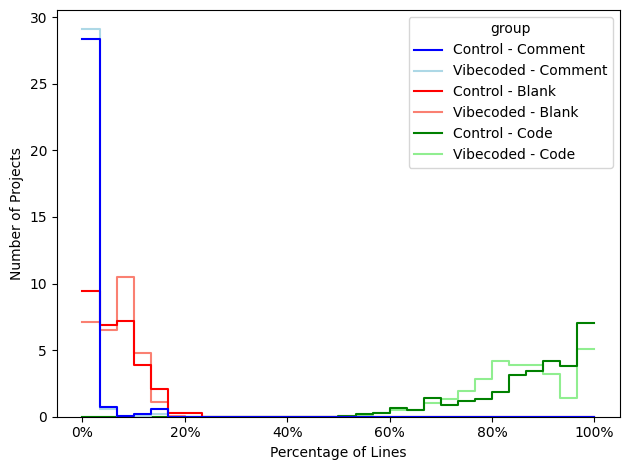

In [446]:
make_graph(df_class, columns = ["percent_comments", "percent_blank", "percent_code"])

In [447]:
filtered_df = df_class[df_class["percent_comments"] < 0]

In [448]:
filtered_df.shape

(0, 46)

In [449]:
filtered_df.iloc[0]

IndexError: single positional indexer is out-of-bounds

In [450]:
print(filtered_df.class_code.iloc[0])

IndexError: single positional indexer is out-of-bounds

# Function level

In [451]:
df_fn = pd.read_csv("../fn_level_metrics.csv")

/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_41841/848191617.py:1: DtypeWarning: Columns (0: origin_class) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fn = pd.read_csv("../fn_level_metrics.csv")


In [452]:
df_fn.columns

Index(['Unnamed: 0', 'url', 'commit', 'proj_name', 'file_path', 'file_name',
       'fn_name', 'fn_sig', 'n_args', 'line_count', 'fn_called', 'var_list',
       'fn_code', 'is_aysnc', 'n_vars', 'n_called', 'n_blank_lines',
       'n_characters', 'n_line_comments', 'line_comment_lines',
       'n_block_comments', 'block_comment_lines', 'block_comment_blank_line',
       'double_count_lines', 'n_same_file_calls', 'n_imported_calls',
       'called_in_files', 'n_times_imported', 'origin_class',
       'import_locations', 'cyclomatic_complexity', 'source', 'n_code_lines',
       'total_lines', 'n_comments_lines', 'n_comments', 'n_vars_by_line',
       'percent_comments', 'percent_blank', 'percent_code',
       'avg_lines_in_comment', 'n_characters_total_by_line',
       'n_code_lines_by_line', 'n_called_by_line', 'n_args_by_line',
       'n_total_calls', 'n_lines_in_proj', 'n_times_imported_by_file',
       'n_total_calls_by_total', 'n_times_called_outside_by_total',
       'n_times_called

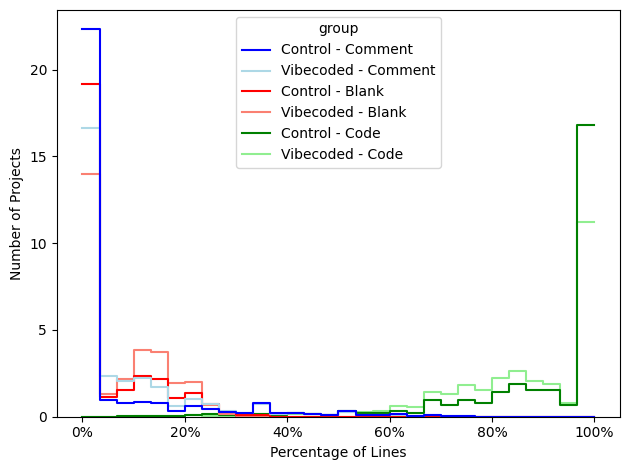

In [453]:
make_graph(df_fn, columns = ["percent_comments", "percent_blank", "percent_code"])

In [454]:
filtered_df = df_fn[df_fn["percent_code"] < 0]
filtered_df.shape

(0, 51)

In [455]:
filtered_df.iloc[0]

IndexError: single positional indexer is out-of-bounds

In [456]:
df_fn.value_counts("percent_comments")

percent_comments
0.000000    95752
0.333333     3198
0.166667     2564
0.200000     2514
0.142857     2348
            ...  
0.129771        1
0.862595        1
0.758065        1
0.775000        1
0.006452        1
Name: count, Length: 2730, dtype: int64

# All

In [457]:
def make_graph(df, columns, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    # whatever preparation you already do
    df_long = df.melt(
        id_vars="source",
        value_vars=columns,
        var_name="line_type",
        value_name="percent"
    )

    # your existing plotting code
    sns.histplot(
        data=df_long,
        x="percent",
        hue="group",
        bins=30,
        element="step",
        fill=False,
        stat="density",
        common_norm=False,
        ax=ax
    )

    return ax

In [466]:



def make_combined_figure(
    dfs,
    titles,
    columns=["percent_comments", "percent_blank", "percent_code"],
    figsize=(12, 9),
    xlim=(0, 1),
    bins=30
):
    """
    Create four histogram plots in a 2x2 figure.

    Each plot contains six distributions:
        Control - Comments
        Vibecoded - Comments
        Control - Blank
        Vibecoded - Blank
        Control - Code
        Vibecoded - Code

    All four plots use identical x and y axes.
    """

    if len(dfs) != 4:
        raise ValueError("You must provide exactly four DataFrames.")

    if len(titles) != 4:
        raise ValueError("You must provide exactly four titles.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=False,
        sharey=True
    )

    palette = {
        "Control - Comments": "blue",
        "Vibecoded - Comments": "lightblue",
        "Control - Blank": "red",
        "Vibecoded - Blank": "salmon",
        "Control - Code": "green",
        "Vibecoded - Code": "lightgreen"
    }

    for ax, df, title in zip(axes.flat, dfs, titles):

        # Convert dataframe to long format
        df_long = df.melt(
            id_vars="source",
            value_vars=columns,
            var_name="line_type",
            value_name="percent"
        )

        # Cleaner names
        df_long["line_type"] = df_long["line_type"].replace({
            "percent_comments": "Comments",
            "percent_blank": "Blank",
            "percent_code": "Code"
        })

        # Rename groups if necessary
        df_long["source"] = df_long["source"].replace({
            "SideProject": "Control",
            "Vibecoding": "Vibecoded"
        })

        # Create the six groups used by hue
        df_long["group"] = (
            df_long["source"].astype(str)
            + " - "
            + df_long["line_type"].astype(str)
        )

        # #kde plot
        sns.kdeplot(
            data=df_long,
            x="percent",
            hue="group",
            common_norm=False,
            fill=True,
            palette=palette,
            ax=ax
        )


        #histogram with true counts, (should probably not normalize axis)
        # sns.histplot(
        #     data=df_long,
        #     x="percent",
        #     hue="group",
        #     bins=bins,
        #     element="step",
        #     fill=False,
        #     stat="count",
        #     common_norm=False,
        #     palette=palette,
        #     ax=ax
        # )

        #histogram with a kde plot added, with a density metric 
        # sns.histplot(
        #     data=df_long,
        #     x="percent",
        #     hue="group",
        #     bins=bins,
        #     element="step",
        #     fill=True,
        #     stat="density",
        #     common_norm=False,
        #     ax=ax,
        #     kde=True,
        #     palette=palette
        # )

        ax.set_title(title)
        ax.set_xlim(*xlim)
        # ax.set_xlabel(f"Percentage of {title} in each category")
        # ax.set_ylabel("Count")

    # Find maximum y-axis after all distributions are plotted
    ymax = max(ax.get_ylim()[1] for ax in axes.flat)
    # ymin = min(ax.get_ylim()[1] for ax in axes.flat)

    # Give every graph exactly the same axes
    for ax, title in zip(axes.flat, titles):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.set_xlim(*xlim)
        ax.set_ylim(0, ymax)

        # Force x tick labels to appear on ALL four graphs
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.yaxis.set_tick_params(labelleft=True)

        # Force axis titles to appear on ALL four graphs
        ax.set_xlabel(
            f"Percentage of Lines by Line Type",
            labelpad=8
        )
        ax.set_ylabel("Estimated Probability Density")


    # Remove Seaborn's individual legends
    for ax in axes.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    # Manually create legend entries
    legend_handles = [
        Patch(
            facecolor="blue",
            edgecolor="blue",
            alpha=0.35,
            label="Human-Written - Comments"
        ),
        Patch(
            facecolor="lightblue",
            edgecolor="lightblue",
            alpha=0.35,
            label="Vibe Coded - Comments"
        ),
        Patch(
            facecolor="red",
            edgecolor="red",
            alpha=0.35,
            label="Human-Written - Blank"
        ),
        Patch(
            facecolor="salmon",
            edgecolor="salmon",
            alpha=0.35,
            label="Vibe Coded - Blank"
        ),
        Patch(
            facecolor="green",
            edgecolor="green",
            alpha=0.35,
            label="Human-Written - Code"
        ),
        Patch(
            facecolor="lightgreen",
            edgecolor="lightgreen",
            alpha=0.35,
            label="Vibe Coded - Code"
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,
        fontsize=14,
        frameon=True,
        handlelength=2.5,
        handleheight=1.5,
        columnspacing=2.5,
        labelspacing=1.0,
        borderpad=.8
    )

    # Reserve enough room for the legend
    fig.tight_layout(rect=[0, 0, 1, 0.84])

    # fig.tight_layout()

    return fig, axes

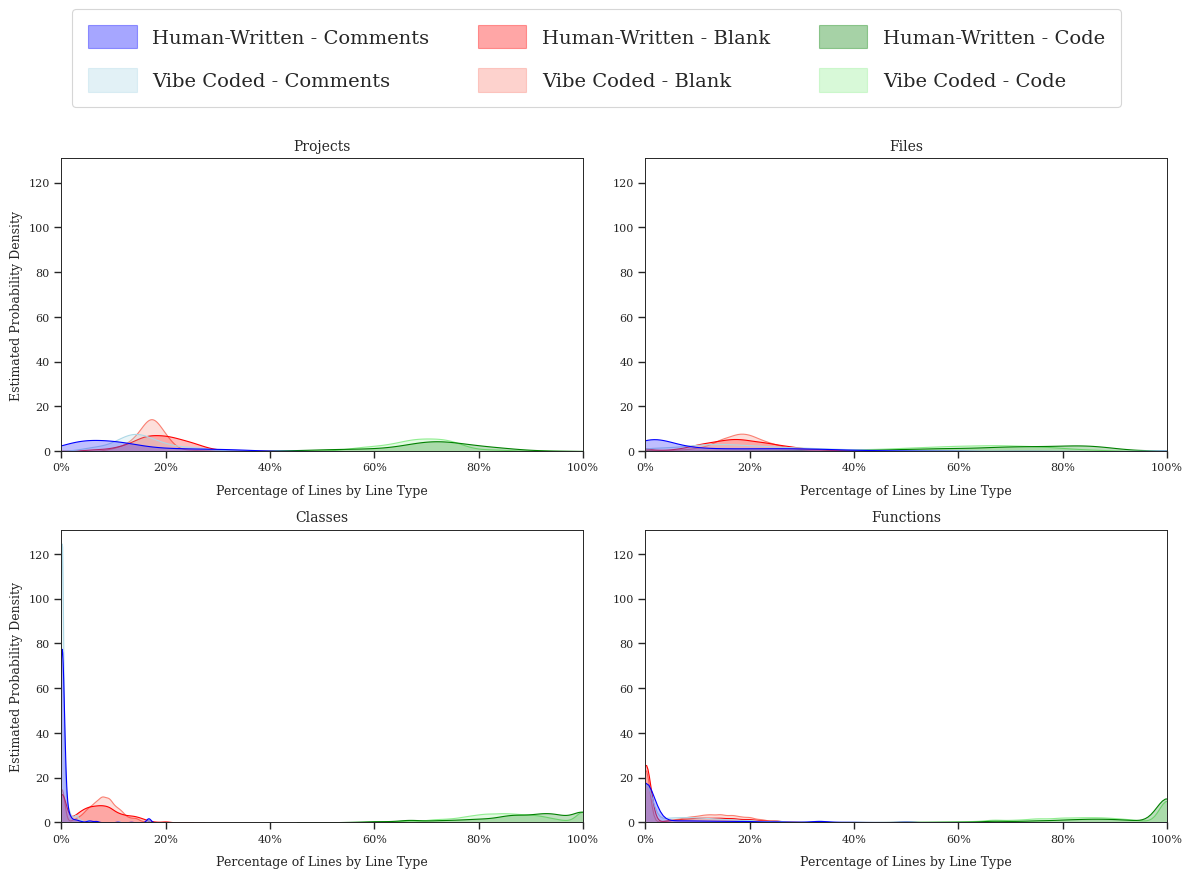

In [467]:
fig, axes = make_combined_figure(
    dfs=[
        df_proj,
        df_file,
        df_class,
        df_fn,
        
        
        
    ],
    titles=[
        "Projects",
        "Files",
        "Classes",
        "Functions",
        
        
       
    ]
)

plt.show()

In [460]:
def make_combined_figure(
    dfs,
    titles,
    columns=["percent_comments", "percent_blank", "percent_code"],
    figsize=(12, 9),
    xlim=(0, 1),
    bins=30
):
    """
    Create four histogram plots in a 2x2 figure.

    Each plot contains six distributions:
        Control - Comments
        Vibecoded - Comments
        Control - Blank
        Vibecoded - Blank
        Control - Code
        Vibecoded - Code

    All four plots use identical x and y axes. Y-axis shows the
    percent of observations (within each group) falling into each bin.
    """

    if len(dfs) != 4:
        raise ValueError("You must provide exactly four DataFrames.")

    if len(titles) != 4:
        raise ValueError("You must provide exactly four titles.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=False,
        sharey=True
    )

    palette = {
        "Control - Comments": "blue",
        "Vibecoded - Comments": "lightblue",
        "Control - Blank": "red",
        "Vibecoded - Blank": "salmon",
        "Control - Code": "green",
        "Vibecoded - Code": "lightgreen"
    }

    # Shared bin edges so every group/plot uses identical bins
    bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)

    for ax, df, title in zip(axes.flat, dfs, titles):

        # Convert dataframe to long format
        df_long = df.melt(
            id_vars="source",
            value_vars=columns,
            var_name="line_type",
            value_name="percent"
        )

        # Cleaner names
        df_long["line_type"] = df_long["line_type"].replace({
            "percent_comments": "Comments",
            "percent_blank": "Blank",
            "percent_code": "Code"
        })

        # Rename groups if necessary
        df_long["source"] = df_long["source"].replace({
            "SideProject": "Control",
            "Vibecoding": "Vibecoded"
        })

        # Create the six groups used by hue
        df_long["group"] = (
            df_long["source"].astype(str)
            + " - "
            + df_long["line_type"].astype(str)
        )

        # Histogram normalized to percent WITHIN each group
        # (stat="percent" + common_norm=False means each of the six
        # groups sums to 100% independently, so bar heights answer
        # "what % of this group's observations fall in this bin?")
        sns.histplot(
            data=df_long,
            x="percent",
            hue="group",
            bins=bin_edges,
            element="step",
            fill=True,
            stat="percent",
            common_norm=False,
            palette=palette,
            alpha=0.35,
            ax=ax
        )

        ax.set_title(title)
        ax.set_xlim(*xlim)

    # Find maximum y-axis after all distributions are plotted
    ymax = max(ax.get_ylim()[1] for ax in axes.flat)

    # Give every graph exactly the same axes
    for ax, title in zip(axes.flat, titles):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.yaxis.set_major_formatter(PercentFormatter(100))  # y is already in percent units
        ax.set_xlim(*xlim)
        ax.set_ylim(0, ymax)

        # Force x tick labels to appear on ALL four graphs
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.yaxis.set_tick_params(labelleft=True)

        # Force axis titles to appear on ALL four graphs
        ax.set_xlabel(
            f"Percentage of Lines by Line Type",
            labelpad=8
        )
        ax.set_ylabel("Percent of Observations")

    # Remove Seaborn's individual legends
    for ax in axes.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    # Manually create legend entries
    legend_handles = [
        Patch(facecolor="blue", edgecolor="blue", alpha=0.35, label="Control - Comments"),
        Patch(facecolor="lightblue", edgecolor="lightblue", alpha=0.35, label="Vibecoded - Comments"),
        Patch(facecolor="red", edgecolor="red", alpha=0.35, label="Control - Blank"),
        Patch(facecolor="salmon", edgecolor="salmon", alpha=0.35, label="Vibecoded - Blank"),
        Patch(facecolor="green", edgecolor="green", alpha=0.35, label="Control - Code"),
        Patch(facecolor="lightgreen", edgecolor="lightgreen", alpha=0.35, label="Vibecoded - Code")
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,
        fontsize=14,
        frameon=True,
        handlelength=2.5,
        handleheight=1.5,
        columnspacing=2.5,
        labelspacing=1.0,
        borderpad=.8
    )

    # Reserve enough room for the legend
    fig.tight_layout(rect=[0, 0, 1, 0.84])

    return fig, axes

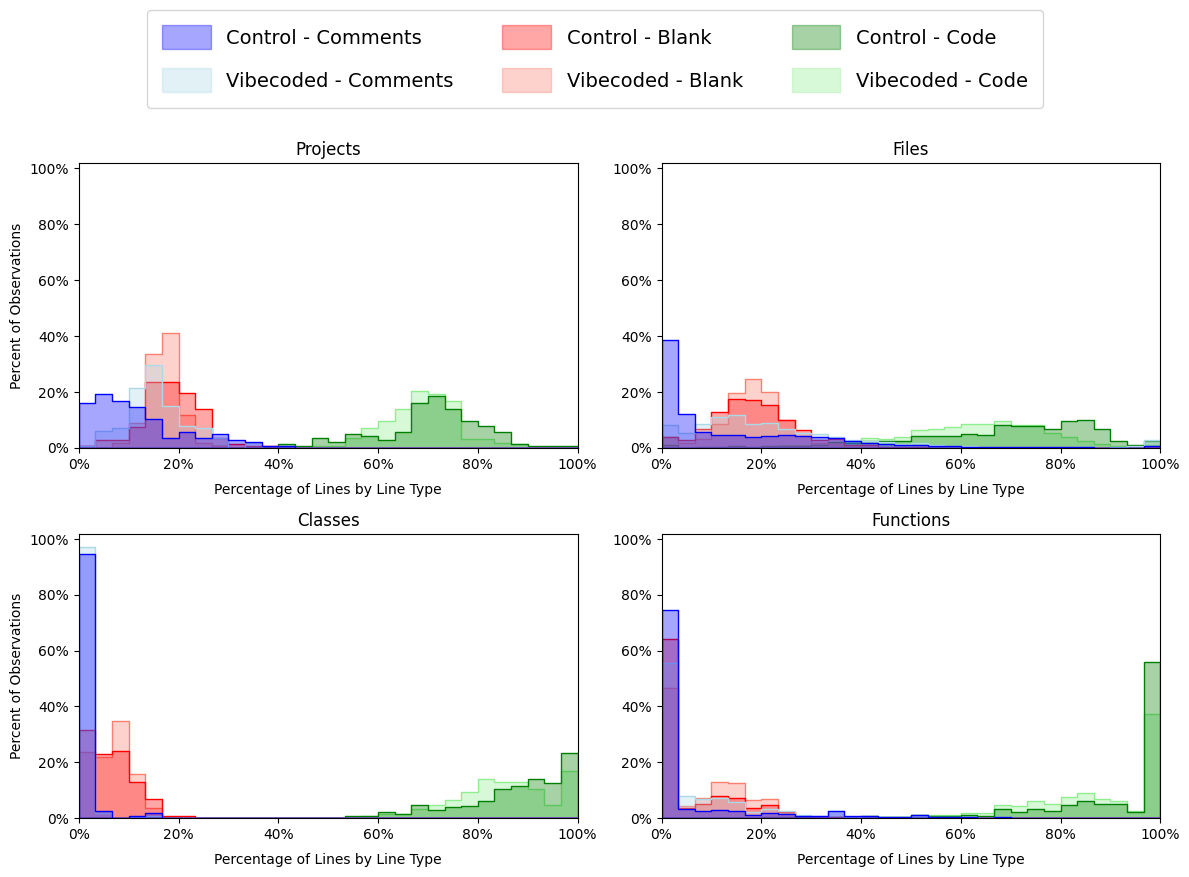

In [ ]:
fig, axes = make_combined_figure(
    dfs=[df_proj, df_file, df_class, df_fn],
    titles=["Projects", "Files", "Classes", "Functions"],
)

plt.show()
plt.savefig("percent_comp.pdf", format="pdf")


In [474]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


def make_combined_figure(
    dfs,
    titles,
    columns=("percent_comments", "percent_blank", "percent_code"),
    figsize=(7.2, 5.4),
    xlim=(0, 1),
    bins=30
):
    """
    Create a publication-ready 2x2 histogram figure comparing
    Control and Vibecoded distributions.

    Encoding:
        Color:
            Blue   = Comments
            Orange = Blank
            Green  = Code

        Pattern:
            Filled  = Control
            Hatched = Vibecoded

    Each source/line-type distribution is normalized independently
    so that its histogram sums to 100%.

    The underlying data are not modified.
    """

    if len(dfs) != 4:
        raise ValueError("You must provide exactly four DataFrames.")

    if len(titles) != 4:
        raise ValueError("You must provide exactly four titles.")

    # ---------------------------------------------------------
    # Publication formatting
    # ---------------------------------------------------------

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # Color represents line type
    colors = {
        "Comments": "#0072B2",
        "Blank": "#D55E00",
        "Code": "#009E73",
    }

    line_types = ["Comments", "Blank", "Code"]
    sources = ["Human-Written", "Vibe Coded"]

    # ---------------------------------------------------------
    # Figure
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    # Exactly the same bins for every distribution
    bin_edges = np.linspace(
        xlim[0],
        xlim[1],
        bins + 1
    )

    # ---------------------------------------------------------
    # Plot each level
    # ---------------------------------------------------------

    for ax, df, title in zip(
        axes.flat,
        dfs,
        titles
    ):

        # Convert to long format
        df_long = df.melt(
            id_vars="source",
            value_vars=columns,
            var_name="line_type",
            value_name="percent"
        )

        # Clean line-type labels
        df_long["line_type"] = df_long["line_type"].replace({
            "percent_comments": "Comments",
            "percent_blank": "Blank",
            "percent_code": "Code"
        })

        # Clean source labels
        df_long["source"] = df_long["source"].replace({
            "SideProject": "Human-Written",
            "Vibecoding": "Vibe Coded"
        })

        # -----------------------------------------------------
        # Plot all six distributions
        # -----------------------------------------------------

        for line_type in line_types:

            for source in sources:

                values = df_long.loc[
                    (df_long["line_type"] == line_type)
                    & (df_long["source"] == source),
                    "percent"
                ]

                # Normalize THIS distribution to 100%
                weights = (
                    np.ones(len(values))
                    * 100
                    / len(values)
                )

                if source == "Human-Written":

                    # Filled distribution
                    ax.hist(
                        values,
                        bins=bin_edges,
                        weights=weights,
                        histtype="stepfilled",
                        facecolor=colors[line_type],
                        edgecolor=colors[line_type],
                        alpha=0.25,
                        linewidth=0.9,
                        zorder=2
                    )

                else:

                    # Hatched distribution
                    ax.hist(
                        values,
                        bins=bin_edges,
                        weights=weights,
                        histtype="stepfilled",
                        facecolor="none",
                        edgecolor=colors[line_type],

                        # Less dense than //// for readability
                        hatch="//",

                        linewidth=1.0,
                        zorder=3
                    )

        # -----------------------------------------------------
        # Panel formatting
        # -----------------------------------------------------

        ax.set_title(
            title,
            pad=4,
            fontweight="semibold"
        )

        ax.set_xlim(*xlim)

        # Horizontal reference grid only
        ax.grid(
            axis="y",
            linewidth=0.4,
            alpha=0.20,
            zorder=0
        )

        ax.grid(
            axis="x",
            visible=False
        )

        # Thin plot borders
        for spine in ax.spines.values():
            spine.set_linewidth(0.7)

    # ---------------------------------------------------------
    # Shared y-axis
    # ---------------------------------------------------------

    ymax = max(
        ax.get_ylim()[1]
        for ax in axes.flat
    )

    # Round upward to nearest 20 percentage points.
    # This will normally give 100% for your current data.
    ymax = np.ceil(ymax / 20) * 20

    # Never exceed 100% for a percentage histogram
    ymax = min(ymax, 100)

    for ax in axes.flat:

        ax.set_xlim(*xlim)
        ax.set_ylim(0, ymax)

        ax.xaxis.set_major_formatter(
            PercentFormatter(1)
        )

        ax.yaxis.set_major_formatter(
            PercentFormatter(100)
        )

        ax.tick_params(
            axis="both",
            direction="out",
            length=3,
            width=0.7
        )

        # Remove individual labels; shared labels are below
        ax.set_xlabel("")
        ax.set_ylabel("")

    # ---------------------------------------------------------
    # Shared axis labels
    # ---------------------------------------------------------

    fig.supxlabel(
        "Percentage of lines",
        fontsize=9,
        y=0.025
    )

    fig.supylabel(
        "Percentage of observations",
        fontsize=9,
        x=0.025
    )

    # ---------------------------------------------------------
    # Legend 1: LINE TYPE
    #
    # Color has exactly one meaning.
    # ---------------------------------------------------------

    line_type_handles = [
        Patch(
            facecolor=colors["Comments"],
            edgecolor=colors["Comments"],
            alpha=0.55,
            label="Comments"
        ),

        Patch(
            facecolor=colors["Blank"],
            edgecolor=colors["Blank"],
            alpha=0.55,
            label="Blank"
        ),

        Patch(
            facecolor=colors["Code"],
            edgecolor=colors["Code"],
            alpha=0.55,
            label="Code"
        )
    ]

    line_type_legend = fig.legend(
        handles=line_type_handles,
        loc="upper center",
        bbox_to_anchor=(0.35, 0.995),
        ncol=3,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.4,
        borderaxespad=0
    )

    # Keep this legend when adding the second one
    fig.add_artist(line_type_legend)

    # ---------------------------------------------------------
    # Legend 2: SOURCE
    #
    # Pattern has exactly one meaning.
    #
    # Neutral outlines are used here because color is NOT
    # encoding source.
    # ---------------------------------------------------------

    source_handles = [
    Patch(
        facecolor="0.75",
        edgecolor="0.35",
        alpha=0.35,
        linewidth=0.9,
        label="Human-Written"
    ),

    Patch(
        facecolor="white",
        edgecolor="0.35",
        hatch="//",
        linewidth=1.0,
        label="Vibe Coded"
    )
]

    fig.legend(
        handles=source_handles,
        loc="upper center",
        bbox_to_anchor=(0.77, 0.995),
        ncol=2,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.4,
        borderaxespad=0
    )

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------

    fig.subplots_adjust(
        left=0.10,
        right=0.99,
        bottom=0.11,
        top=0.91,
        wspace=0.12,
        hspace=0.22
    )

    return fig, axes

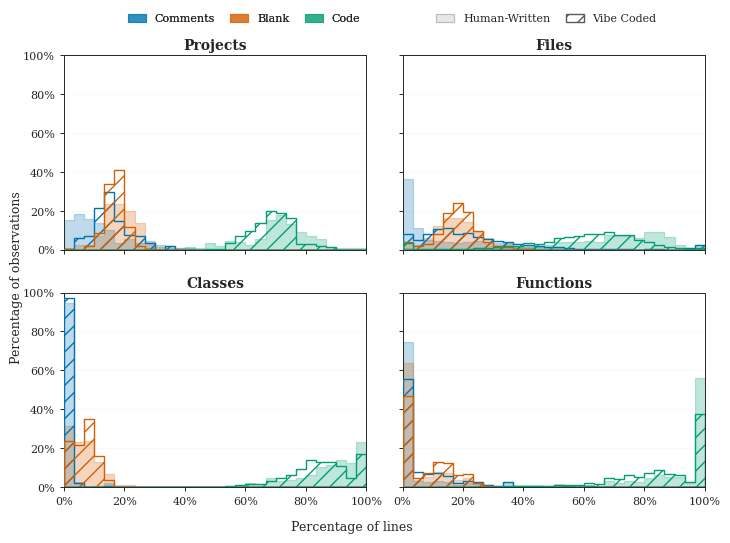

In [475]:
fig, axes = make_combined_figure(
    dfs=[df_proj, df_file, df_class, df_fn],
    titles=["Projects", "Files", "Classes", "Functions"]
)

fig.savefig(
    "line_type_distributions.pdf",
    bbox_inches="tight"
)

Differences in blank lines is due to a bug in how AST unparses functions and classes. Working on fixing it, have to do some weird math, but thats ok. 

# Three-of-a-Kind

In [ ]:



def make_combined_distributions(
    df_proj,
    df_file,
    df_class,
    df_fn,
    bins=30
):
    columns = [
        "percent_comments",
        "percent_blank",
        "percent_code"
    ]

    # Add category labels
    dfs = [
        df_proj.assign(category="Projects"),
        df_file.assign(category="Files"),
        df_class.assign(category="Classes"),
        df_fn.assign(category="Functions")
    ]

    # Combine
    combined = pd.concat(dfs, ignore_index=True)

    # Long format
    df_long = combined.melt(
        id_vars=["source", "category"],
        value_vars=columns,
        var_name="line_type",
        value_name="percent"
    )

    # Cleaner names
    df_long["line_type"] = df_long["line_type"].replace({
        "percent_comments": "Comments",
        "percent_blank": "Blank",
        "percent_code": "Code"
    })

    df_long["source"] = df_long["source"].replace({
        "SideProject": "Control",
        "Vibecoding": "Vibecoded"
    })

    # Category colors
    colors = {
        "Projects": "blue",
        "Files": "orange",
        "Classes": "green",
        "Functions": "red"
    }

    # Source line styles
    linestyles = {
        "Control": "-",
        "Vibecoded": "--"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
        sharex=True,
        sharey=True
    )

    for ax, line_type in zip(
        axes,
        ["Comments", "Blank", "Code"]
    ):

        metric_df = df_long[
            df_long["line_type"] == line_type
        ]

        for category in [
            "Projects",
            "Files",
            "Classes",
            "Functions"
        ]:

            for source in [
                "Control",
                "Vibecoded"
            ]:

                subset = metric_df[
                    (metric_df["category"] == category)
                    & (metric_df["source"] == source)
                ]

                sns.histplot(
                    data=subset,
                    x="percent",
                    bins=bins,
                    element="step",
                    fill=True,
                    stat="density",
                    common_norm=False,
                    color=colors[category],
                    linestyle=linestyles[source],
                    label=f"{category} - {source}",
                    ax=ax
                )

        # for category in [
        #         "Projects",
        #         "Files",
        #         "Classes",
        #         "Functions"
        #     ]:
        #     for source in ["Control", "Vibecoded"]:

        #         subset = metric_df[
        #             (metric_df["category"] == category)
        #             & (metric_df["source"] == source)
        #         ]

        #         hatch = None if source == "Control" else "///"

        #         ax.hist(
        #             subset["percent"].dropna(),
        #             bins=bins,
        #             density=True,
        #             histtype="stepfilled",
        #             facecolor=colors[category],
        #             edgecolor=colors[category],
        #             alpha=0.25,
        #             hatch=hatch,
        #             label=f"{category} - {source}"
        #         )

                ax.set_title(line_type)
                ax.set_xlim(0, 1)
                ax.xaxis.set_major_formatter(
                    PercentFormatter(1)
                )

                ax.set_xlabel("Percentage of Lines by Line Type")
                ax.set_ylabel("Estimated Probability Density")

    # Make y-axis labels visible on all three
    for ax in axes:
        ax.tick_params(
            axis="both",
            labelleft=True,
            labelbottom=True
        )

    # Use only one legend
    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=4
    )

    plt.tight_layout()

    return fig, axes

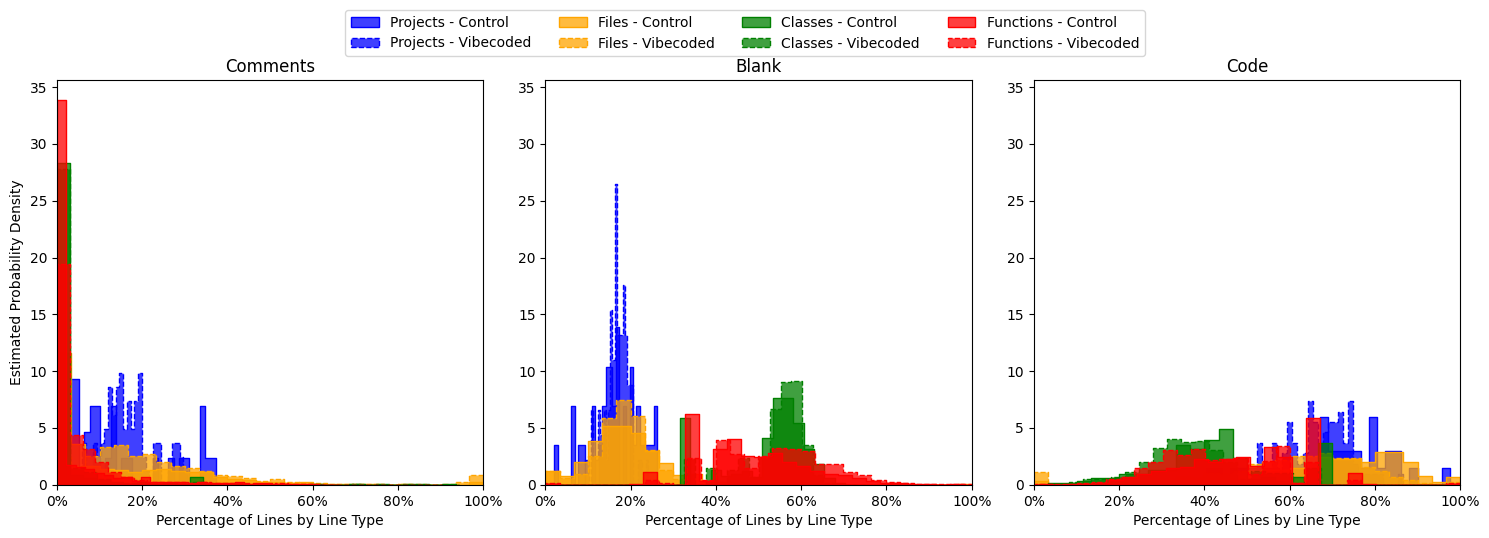

In [ ]:
g = make_combined_distributions(
    df_proj,
    df_file,
    df_class,
    df_fn
)

plt.show()

# Percentage Comments by File Length

In [ ]:
df_file.columns

Index(['Unnamed: 0', 'url_x', 'proj_name', 'file_path', 'file_name', 'extn',
       'n_lines', 'blank_lines', 'char', 'source', 'n_functions',
       'n_async_functions', 'class_count', 'n_at_end_of_code_line_block',
       'n_at_end_of_code_line_line', 'n_blank_in_docstring_block',
       'n_blank_in_docstring_line', 'n_comment_lines_block',
       'n_comment_lines_line', 'n_comments_block', 'n_comments_line',
       'n_imports', 'n_fn_imports', 'n_class_imports', 'url', 'n_calls',
       'n_unique_fn_calls', 'n_unique_class_calls', 'n_comments_lines',
       'n_comments', 'avg_lines_in_comment', 'n_code_lines', 'blank_by_code',
       'percent_comments', 'char_by_code', 'n_functions_by_code',
       'n_async_functions_by_code', 'class_count_by_code',
       'n_comment_lines_block_by_code', 'n_comment_lines_line_by_code',
       'n_imports_by_code', 'n_calls_by_code', 'n_comments_block_by_code',
       'n_comments_line_by_code', 'avg_len_block_comment',
       'avg_len_line_comment', 

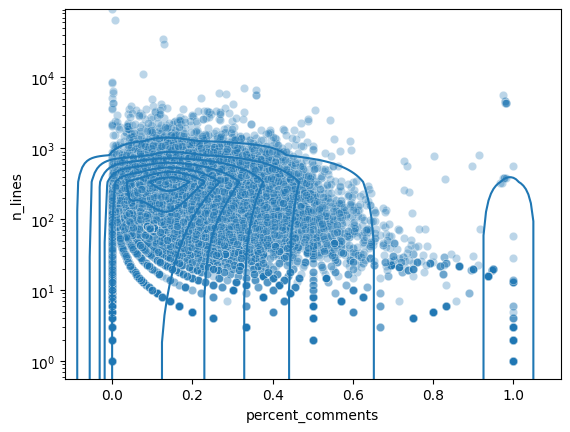

In [ ]:


sns.scatterplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    alpha=0.3
)

sns.kdeplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    levels=8,
    linewidths=1.5
)
plt.yscale('log')

plt.show()

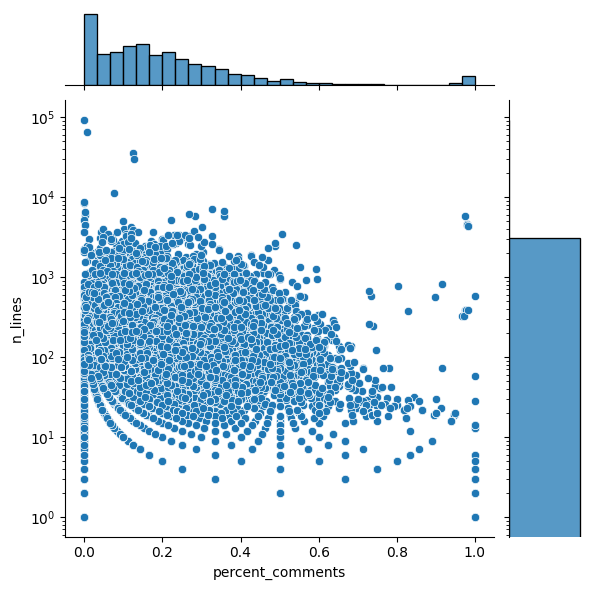

In [ ]:
sns.jointplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    kind="scatter",
    marginal_kws={"bins": 30}
)
plt.yscale('log')

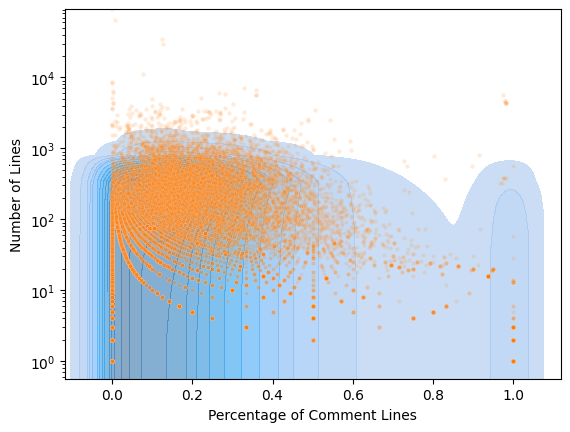

In [ ]:
sns.kdeplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    fill=True,
    levels=20,
    thresh=0.02,
    alpha=0.6
)

sns.scatterplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    alpha=0.15,
    s=10
)

plt.xlabel("Percentage of Comment Lines")
plt.ylabel("Number of Lines")

plt.yscale('log')
plt.show()

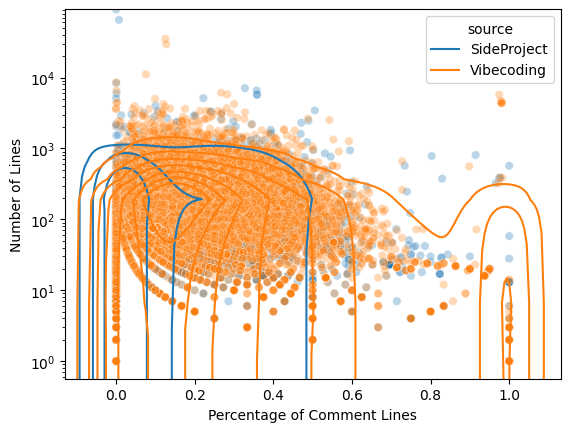

In [ ]:
ax = sns.scatterplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    hue="source",
    alpha=0.3
)

sns.kdeplot(
    data=df_file,
    x="percent_comments",
    y="n_lines",
    hue="source",
    levels=8,
    linewidths=1.5,
    ax=ax
)

plt.xlabel("Percentage of Comment Lines")
plt.ylabel("Number of Lines")
plt.yscale('log')
plt.show()

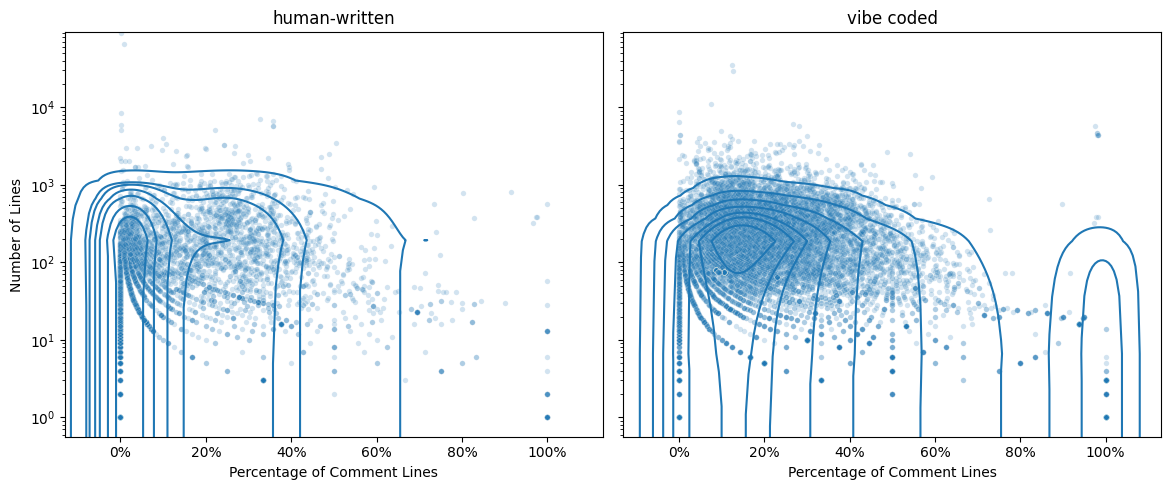

In [ ]:

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["human-written", "vibe coded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_file[df_file["source"] == source]

    # Scatter points
    sns.scatterplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        alpha=0.2,
        s=15,
        ax=ax
    )

    # Density contours
    sns.kdeplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        levels=8,
        linewidths=1.5,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("Number of Lines")

    ax.xaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
for ax in axes:
    ax.set_yscale("log")
plt.show()

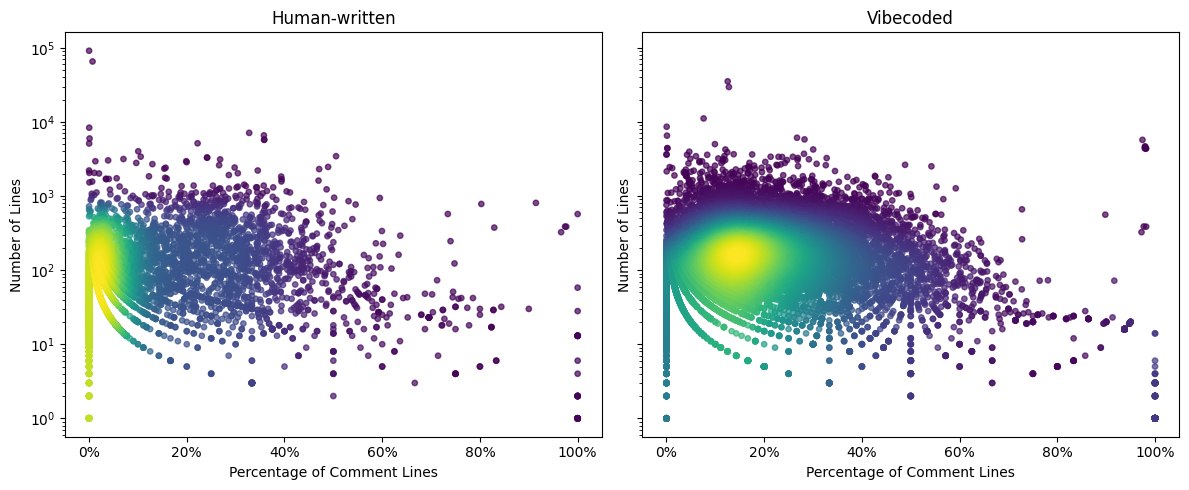

In [ ]:


fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["Human-written", "Vibecoded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_file[
        df_file["source"] == source
    ].dropna(subset=["percent_comments", "n_lines"])

    x = subset["percent_comments"].to_numpy()
    y = subset["n_lines"].to_numpy()

    # Calculate 2D density
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    # Sort so high-density points are plotted last
    order = density.argsort()

    x = x[order]
    y = y[order]
    density = density[order]

    # Scatter plot colored by density
    scatter = ax.scatter(
        x,
        y,
        c=density,
        cmap="viridis",
        s=15,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("Number of Lines")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )
for ax in axes:
    ax.set_yscale("log")
plt.tight_layout()
plt.show()

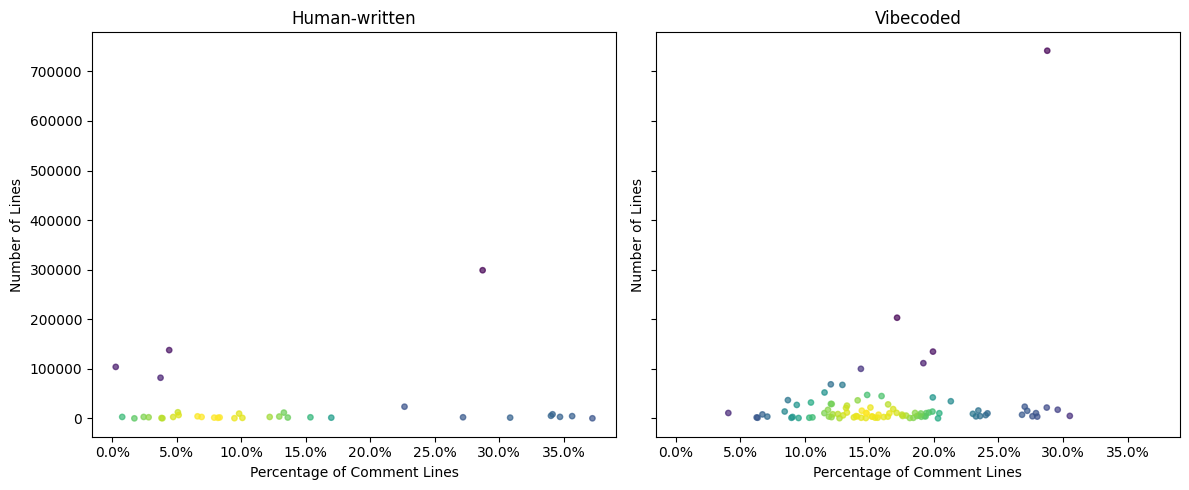

In [ ]:


fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["Human-written", "Vibecoded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_proj[
        df_proj["source"] == source
    ].dropna(subset=["percent_comments", "n_lines"])

    x = subset["percent_comments"].to_numpy()
    y = subset["n_lines"].to_numpy()

    # Calculate 2D density
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    # Sort so high-density points are plotted last
    order = density.argsort()

    x = x[order]
    y = y[order]
    density = density[order]

    # Scatter plot colored by density
    scatter = ax.scatter(
        x,
        y,
        c=density,
        cmap="viridis",
        s=15,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("Number of Lines")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )
# for ax in axes:
#     ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
df_proj.shape

(128, 37)

In [ ]:
df_file.shape

(17779, 53)

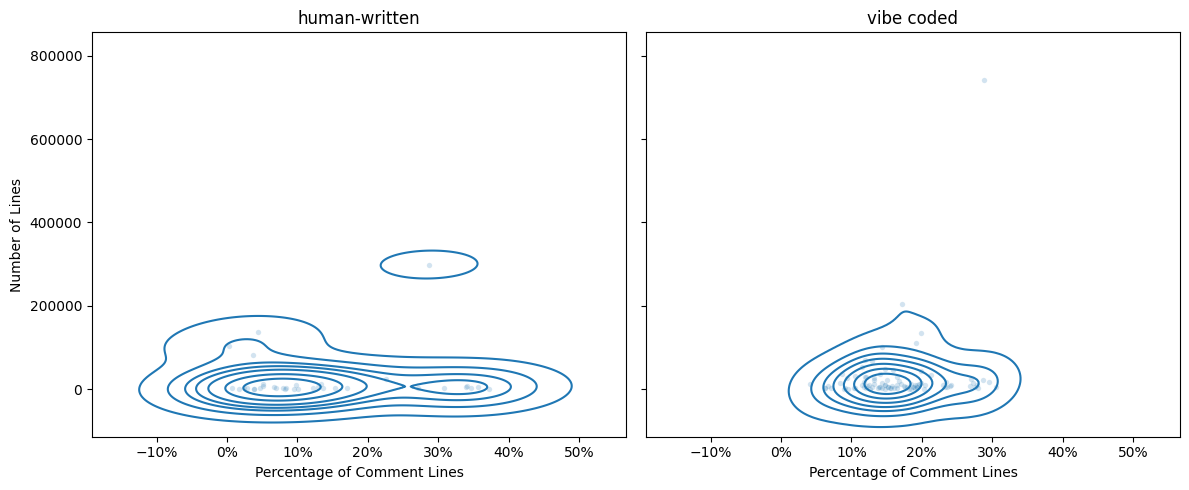

In [ ]:

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["human-written", "vibe coded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_proj[df_proj["source"] == source]

    # Scatter points
    sns.scatterplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        alpha=0.2,
        s=15,
        ax=ax
    )

    # Density contours
    sns.kdeplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        levels=8,
        linewidths=1.5,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("Number of Lines")

    ax.xaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
# for ax in axes:
#     ax.set_yscale("log")
plt.show()

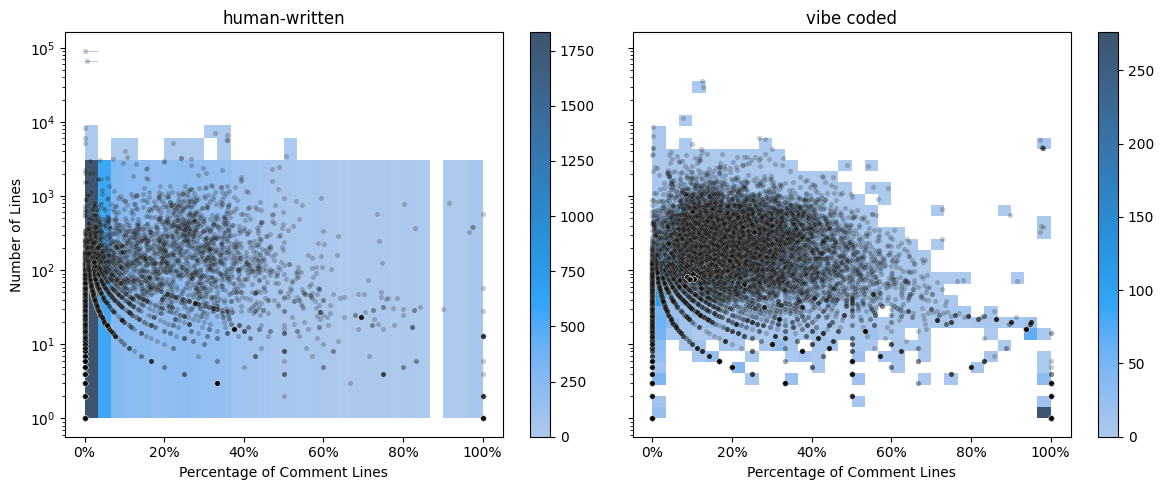

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["human-written", "vibe coded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_file[df_file["source"] == source]

    # Raw density: number of observations in each 2D bin
    sns.histplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        bins=30,
        stat="count",
        cbar=True,
        ax=ax
    )

    # Scatter points on top
    sns.scatterplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        alpha=0.2,
        s=15,
        color="black",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("Number of Lines")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

    ax.set_yscale("log")

plt.tight_layout()
plt.show()

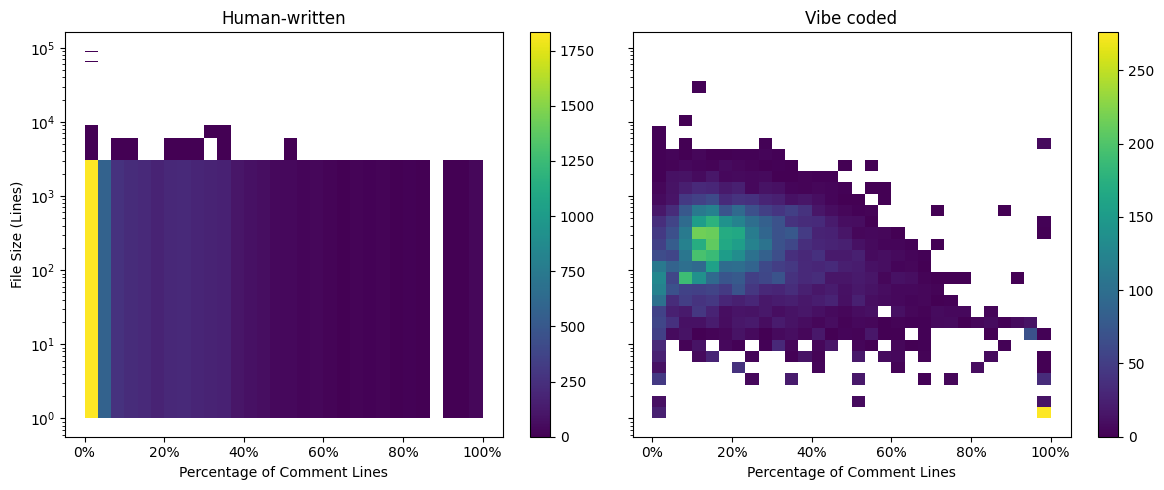

In [ ]:


fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["Human-written", "Vibe coded"]

for ax, source, title in zip(axes, sources, titles):

    subset = df_file[df_file["source"] == source]

    sns.histplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        bins=30,
        stat="count",      # color represents number of files in each bin
        cmap="viridis",
        cbar=True,
        ax=ax
    )
    ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("File Size (Lines)")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

plt.tight_layout()
plt.show()

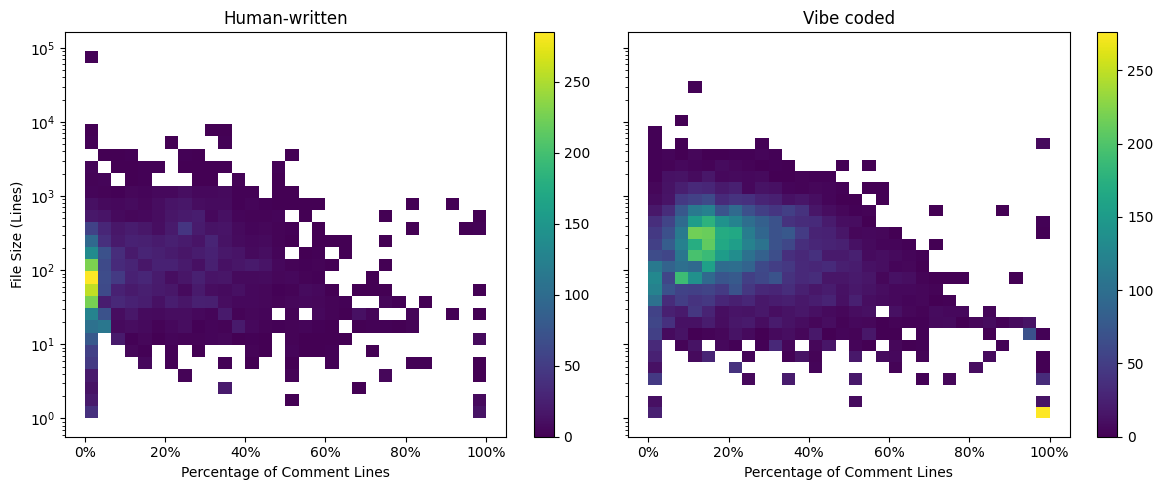

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["Human-written", "Vibe coded"]

# Set log scale BEFORE either histogram is created
for ax in axes:
    ax.set_yscale("log")

for ax, source, title in zip(axes, sources, titles):

    subset = df_file[df_file["source"] == source]

    sns.histplot(
        data=subset,
        x="percent_comments",
        y="n_lines",
        bins=30,
        stat="count",
        cmap="viridis",
        cbar=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("File Size (Lines)")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

plt.tight_layout()
plt.show()

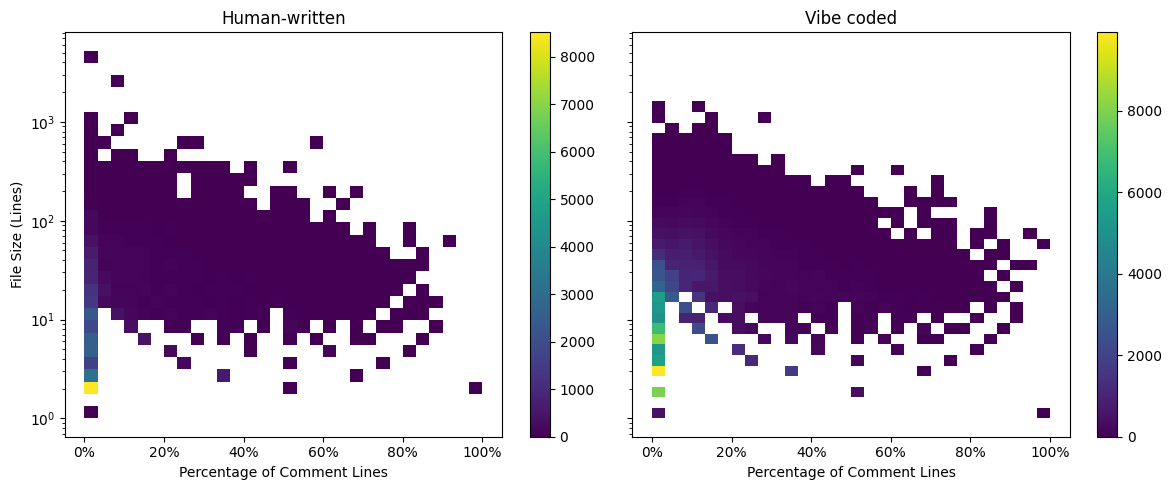

In [ ]:



fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

sources = ["SideProject", "Vibecoding"]
titles = ["Human-written", "Vibe coded"]

# Set log scale BEFORE either histogram is created
for ax in axes:
    ax.set_yscale("log")

for ax, source, title in zip(axes, sources, titles):

    subset = df_fn[df_fn["source"] == source]

    sns.histplot(
        data=subset,
        x="percent_comments",
        y="line_count",
        bins=30,
        stat="count",
        cmap="viridis",
        cbar=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Percentage of Comment Lines")
    ax.set_ylabel("File Size (Lines)")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

plt.tight_layout()
plt.show()